In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt


In [3]:
pd.set_option('display.max_columns', 350)
pd.set_option('display.max_rows', 350)

In [4]:
runs_folders = [
    # "/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations/runs-rebuttal-default",
    "/home/bulatov/rmt/test-time/compressing-associations/runs-rebuttal-default",
]

base_dir = Path("/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations")


In [5]:
all_runs = []
for runs_folder in runs_folders:
    runs_path = Path(runs_folder)
    target_runs = list(runs_path.glob('**/run_*'))
    
    for run_path in target_runs:
        if not run_path.is_dir():
            continue
        # skip checkpoint subdirs
        if 'checkpoint' in str(run_path):
            continue
            
        run_stats = {}
        run_stats['run_path'] = str(run_path)
        run_stats['runs_folder'] = runs_path.name
        run_stats['run_name'] = run_path.parent.name
        run_stats['task_name'] = run_path.parent.parent.name
        run_stats['run_id'] = int(run_path.name.split('_')[1])
        
        config_path = run_path / 'config.json'
        if config_path.exists():
            cli_args = json.load(open(config_path))['cli_args']
            run_stats.update(cli_args)
        
        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path))
            run_stats.update(results)
        else:
            run_stats['eval_exact_match'] = np.nan
            run_stats['eval_token_accuracy'] = np.nan
        all_runs.append(run_stats)
df = pd.DataFrame(all_runs)
# Re-apply cli_args from disk so hyperparameters stay correct if a later cell merged
# path-string columns (e.g. old `extract_params_from_run_path` with misleading `ss` for GDN).
_cfg_rows = []
for rp in df["run_path"]:
    cfg_path = Path(rp) / "config.json"
    if cfg_path.is_file():
        with open(cfg_path) as f:
            _cfg_rows.append(json.load(f).get("cli_args") or {})
    else:
        _cfg_rows.append({})
_cfg_df = pd.DataFrame(_cfg_rows)
for col in _cfg_df.columns:
    df[col] = _cfg_df[col].values

# Drop legacy path-parse columns from older notebook versions (same info lives in cli_* names).
for _c in ("ss", "layers", "dim", "ck"):
    if _c in df.columns:
        df.drop(columns=[_c], inplace=True)

bm = df["base_model"]
_ss = pd.to_numeric(df["state_size"], errors="coerce")
_nh_raw = df["n_head"] if "n_head" in df.columns else pd.Series(1, index=df.index)
_nh = pd.to_numeric(_nh_raw, errors="coerce").fillna(1).replace(0, 1).astype(int)
df["ssm_state_size_N"] = _ss.where(bm.isin(["mamba", "mamba2"]))
df["gdn_head_dim"] = (_ss // _nh).where(bm == "gated_delta_net")

print(f"Total runs: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df



Total runs: 637
Columns: ['run_path', 'runs_folder', 'run_name', 'task_name', 'run_id', 'exp_path', 'per_device_batch_size', 'data_path', 'tokenizer_path', 'gradient_accumulation_steps', 'total_batch_size', 'metric_for_best_model', 'warmup_steps', 'max_steps', 'logging_steps', 'eval_steps', 'weight_decay', 'learning_rate', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'lr_scheduler_type', 'early_stopping_patience', 'seed', 'base_model', 'pretrained_model', 'n_layer', 'n_head', 'n_embd', 'state_size', 'conv_kernel', 'max_position_embeddings', 'max_input_length', 'attn_implementation', 'n_pairs', 'n_keys', 'n_values', 'overwrite_output_dir', 'do_eval_only', 'epoch', 'eval_exact_match', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_token_accuracy', 'num_input_tokens_seen', 'patience', 'ssm_state_size_N', 'gdn_head_dim']


In [6]:
# import re

# def parse_run_name(run_name):
#     info = {}
    
#     m = re.match(r'^(.+?)_L(\d+)H(\d+)D(\d+)(.*)', run_name)
#     if not m:
#         return info
    
#     info['model'] = m.group(1)
#     info['L'] = int(m.group(2))
#     info['H'] = int(m.group(3))
#     info['D'] = int(m.group(4))
#     rest = m.group(5)
    
#     mem_match = re.search(r'_mem(\d+)', rest)
#     if mem_match:
#         info['mem'] = int(mem_match.group(1))
    
#     seg_match = re.search(r'-(\d+x\d+)', rest)
#     if seg_match:
#         info['segment'] = seg_match.group(1)
    
#     return info

# parsed = df['run_name'].apply(parse_run_name).apply(pd.Series)
# df = pd.concat([df, parsed], axis=1)

In [7]:
def calc_recurrent_state_size(row, include_conv=False,
                               mamba_expand=2, mamba2_head_dim=64, gdn_expand_v=2.0):
    """
    Calculate the total recurrent state size (number of scalar elements)
    for mamba / mamba2 / gated_delta_net models.

    Parameters taken directly from a results DataFrame row:
        base_model, n_layer, n_embd, state_size, conv_kernel, n_head (optional, default 1)

    Args:
        row          : pd.Series (a single DataFrame row)
        include_conv : also count the short-conv buffer (conv_kernel-1 elements per channel)
        mamba_expand : expand factor (default 2, matches FLA MambaConfig default)
        mamba2_head_dim : head_dim used by Mamba2 (default 64, matches FLA Mamba2Config default)
        gdn_expand_v : expand_v for GDN value projection (default 2.0, matches GatedDeltaNetConfig default)
    """
    base_model  = row['base_model']
    n_layer     = int(row['n_layer'])
    n_embd      = int(row['n_embd'])
    state_size  = int(row['state_size'])
    conv_kernel = int(row['conv_kernel'])
    n_head      = int(row.get('n_head', 1))

    if base_model in ('mamba', 'mamba2'):
        # d_inner = expand * n_embd  (both architectures default expand=2)
        # SSM state per layer: d_inner × state_size
        # (Mamba2: num_heads = d_inner/head_dim, state shape [H, state_size, head_dim]
        #  → same total: d_inner × state_size)
        d_inner   = mamba_expand * n_embd
        ssm_state = n_layer * d_inner * state_size
        if include_conv:
            # conv buffer per layer: d_inner × (conv_kernel − 1)
            return ssm_state + n_layer * d_inner * (conv_kernel - 1)
        return ssm_state

    elif base_model == 'gated_delta_net':
        # build_fla_config sets: head_dim = state_size // n_head
        # GDN layer:  head_k_dim = head_dim,  head_v_dim = head_dim × expand_v
        # Recurrent state per layer: [num_heads, head_k_dim, head_v_dim]
        head_dim   = state_size // n_head
        head_v_dim = int(head_dim * gdn_expand_v)
        recurrent  = n_layer * n_head * head_dim * head_v_dim
        if include_conv:
            # v_conv1d on value_dim = n_head × head_v_dim channels, depth (conv_size − 1)
            value_dim = n_head * head_v_dim
            return recurrent + n_layer * value_dim * (conv_kernel - 1)
        return recurrent

    else:
        raise ValueError(f"Unsupported base_model: {base_model!r}")

In [8]:
df['recurrent_state_size'] = df.apply(calc_recurrent_state_size, axis=1)
# or with conv buffer included:
df['recurrent_state_size_with_conv'] = df.apply(
    lambda row: calc_recurrent_state_size(row, include_conv=True), axis=1
)

In [9]:
df.shape

(637, 52)

In [10]:
# df['eval_exact_match'] = df['eval_exact_match'].fillna(df['eval_exact_match_base'])
df = df.dropna(subset=['eval_exact_match'])

# df.mem = df.mem.fillna(0).astype(int)
# df.segment = df.segment.fillna('1x' + df.

df['modification'] = ''
df.loc[df.max_steps == 200000, 'modification'] += ' 2x steps'

df['n_pairs'] = df.task_name.apply(lambda x: int(x[1:].split('-')[0]))

In [11]:
# df[df.run_path.apply(lambda x: 'gating-v2' in x)][['run_path', 'run_name', 'eval_exact_match']]

In [12]:
# df.exp_path.unique().tolist()


In [13]:
# df[df.exp_path.apply(lambda x: '1L-1W' in x)]

In [14]:
# -----------------------------------------------------------------------------
# Old approach (commented): parsing run_path gives `_ss...` which matches filename
# tokens but is misleading for gated_delta_net (`state_size` CLI maps to head_dim,
# not SSM state dim N). Prefer merge_params_from_saved_config + semantics below.
# -----------------------------------------------------------------------------
# import re
#
# def extract_params_from_run_path(run_path):
#     """
#     Extract parameters from run_path string.
#     Example:
#       N8-K2V2-V62_1M/mamba2_L4D64_ss16_ck4_bs_64_lr_1e-03_b2_0.999
#       will extract:
#         n_pairs=8, k=2, v=2, Vocab=62, model=mamba2, layers=4,
#         dim=64, ss=16, ck=4, bs=64, lr=1e-03, b2=0.999
#     """
#     params = {}
#
#     # Match dataset info: N8-K2V2-V62_1M
#     ds = re.search(r'N(\d+)-K(\d+)V(\d+)-V(\d+)_1M', run_path)
#     if ds:
#         params['n_pairs'] = int(ds.group(1))
#         params['k'] = int(ds.group(2))
#         params['v'] = int(ds.group(3))
#         params['Vocab'] = int(ds.group(4))
#
#     # Match model and hyperparameters, e.g. mamba2_L4D64_ss16_ck4_bs_64_lr_1e-03_b2_0.999
#     m = re.search(
#         r'/([\w\-]+)_L(\d+)D(\d+)_ss(\d+)_ck(\d+)_bs_(\d+)_lr_([\de\.-]+)(?:_b2_([\d\.]+))?', run_path
#     )
#     if m:
#         params['model'] = m.group(1)
#         params['layers'] = int(m.group(2))
#         params['dim'] = int(m.group(3))
#         params['ss'] = int(m.group(4))
#         params['ck'] = int(m.group(5))
#         params['bs'] = int(m.group(6))
#         params['lr'] = m.group(7)
#         if m.group(8):
#             params['b2'] = float(m.group(8))
#
#     return params
#
# # Example: extract all params from unique run_paths and create a DataFrame
# param_list = [extract_params_from_run_path(x) for x in df.run_path]
# params_df = pd.DataFrame(param_list)
# for col in params_df.columns:
#     df[col] = params_df[col]

import json
from pathlib import Path

import pandas as pd


def load_cli_args_from_exp_config(exp_path):
    """Load `cli_args` from `run_fla_on_kv_retrieval-default` run `config.json`."""
    p = Path(exp_path)
    if not p.is_absolute():
        p = Path.cwd() / p
    p = p.expanduser().resolve()
    cfg_path = p / "config.json"
    if not cfg_path.is_file():
        return {}
    with open(cfg_path) as f:
        blob = json.load(f)
    return dict(blob.get("cli_args") or {})


def merge_params_from_saved_config(df, exp_path_col="exp_path", overwrite=True):
    """
    For each row, read `{exp_path}/config.json` and attach training CLI keys.
    Same fields as saved at train time (authoritative vs path string parsing).

    Note: if you built `df` via the collector that already `update(cli_args)`, this
    is idempotent aside from refreshing from disk when `overwrite=True`.
    """
    records = [load_cli_args_from_exp_config(ep) for ep in df[exp_path_col]]
    cfg_df = pd.DataFrame(records)
    if cfg_df.empty:
        return df
    out = df.copy()
    for col in cfg_df.columns:
        if overwrite or col not in out.columns:
            out[col] = cfg_df[col].values
    return out


def add_state_size_semantics(df):
    """
    Split cfg `state_size` + `base_model` into explicit columns for cross-model plots:
      - `ssm_state_size_N` — SSM latent dim (mamba / mamba2 only)
      - `gdn_head_dim` — FLA GDN head dim from this repo's runner:
            head_dim = state_size // n_head
    """
    out = df.copy()
    bm = out["base_model"]
    ss = pd.to_numeric(out["state_size"], errors="coerce")
    nh_raw = out["n_head"] if "n_head" in out.columns else pd.Series(1, index=out.index)
    nh = pd.to_numeric(nh_raw, errors="coerce").fillna(1).replace(0, 1).astype(int)
    out["ssm_state_size_N"] = ss.where(bm.isin(["mamba", "mamba2"]))
    out["gdn_head_dim"] = (ss // nh).where(bm == "gated_delta_net")
    return out


# Example:
# df = merge_params_from_saved_config(df, exp_path_col="exp_path")
# df = add_state_size_semantics(df)


In [15]:
group_cols = [
    'task_name',              # or ['n_pairs', 'n_keys', 'n_values'] if you prefer explicit task identity
    'base_model',
    'n_layer',
    'n_embd',
    'state_size',
    'conv_kernel',
    # 'learning_rate',
    'recurrent_state_size',
    'recurrent_state_size_with_conv',
    # 'per_device_batch_size',
    # 'adam_beta2',
    # 'max_steps',              # better than grouping by the derived 'modification' label
]

In [16]:
# debug_cols = ['n_pairs', 'model', 'layers', 'dim', 'ss', 'ck', 'bs', 'lr', 'b2']
# df[df[debug_cols].isna().any(axis=1)][
#     ['run_path', 'run_name', 'task_name', 'base_model', 'n_layer', 'n_embd',
#      'state_size', 'conv_kernel', 'per_device_batch_size',
#      'learning_rate', 'adam_beta2', 'max_steps', 'eval_exact_match']
# ].sort_values(['task_name', 'run_name'])

In [17]:
# debug_cols = ['n_pairs', 'model', 'layers', 'dim', 'ss', 'ck', 'bs', 'lr', 'b2']
# df[df[debug_cols].isna().any(axis=1)][
#     ['run_path', 'run_name', 'task_name', 'base_model', 'n_layer', 'n_embd',
#      'state_size', 'conv_kernel', 'per_device_batch_size',
#      'learning_rate', 'adam_beta2', 'max_steps', 'eval_exact_match']
# ].sort_values(['task_name', 'run_name'])

In [18]:
df.columns

Index(['run_path', 'runs_folder', 'run_name', 'task_name', 'run_id',
       'exp_path', 'per_device_batch_size', 'data_path', 'tokenizer_path',
       'gradient_accumulation_steps', 'total_batch_size',
       'metric_for_best_model', 'warmup_steps', 'max_steps', 'logging_steps',
       'eval_steps', 'weight_decay', 'learning_rate', 'adam_beta1',
       'adam_beta2', 'adam_epsilon', 'lr_scheduler_type',
       'early_stopping_patience', 'seed', 'base_model', 'pretrained_model',
       'n_layer', 'n_head', 'n_embd', 'state_size', 'conv_kernel',
       'max_position_embeddings', 'max_input_length', 'attn_implementation',
       'n_pairs', 'n_keys', 'n_values', 'overwrite_output_dir', 'do_eval_only',
       'epoch', 'eval_exact_match', 'eval_loss', 'eval_runtime',
       'eval_samples_per_second', 'eval_steps_per_second',
       'eval_token_accuracy', 'num_input_tokens_seen', 'patience',
       'ssm_state_size_N', 'gdn_head_dim', 'recurrent_state_size',
       'recurrent_state_size_with_co

In [19]:
grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
)
grouped

avg_em  \
task_name       base_model      n_layer n_embd state_size conv_kernel recurrent_state_size recurrent_state_size_with_conv           
N16-K2V2-V62_1M gated_delta_net 1       64     4          2           32                   40                                0.74   
                                4       128    16         2           2048                 2176                             56.03   
                                                          4           2048                 2432                             61.60   
                mamba           4       128    16         2           16384                17408                            98.69   
                                                          4           16384                19456                            98.74   
                mamba2          1       64     4          2           512                  640                               4.17   
                                                          4           512                  896                              23.53   
                                               16         2           2048                 2176                              5.00   
                                                          4           2048                 2432                             65.98   
                                               32         2           4096                 4224                              6.66   
                                                          4           4096                 4480                              7.12   
                                        128    4          2           1024                 1280                              5.65   
                                                          4           1024                 1792                             29.04   
                                               16         2           4096                 4352                              6.54   
                                                          4           4096                 4864                             90.85   
                                               32         2           8192                 8448                              6.99   
                                                          4           8192                 8960                             64.75   
                                        256    4          2           2048                 2560                              6.29   
                                                          4           2048                 3584                             63.06   
                                               16         2           8192                 8704                              6.35   
                                                          4           8192                 9728                             97.53   
                                               32         2           16384                16896                             6.75   
                                                          4           16384                17920                            98.20   
                                2       64     4          2           1024                 1280                              4.05   
                                                          4           1024                 1792                             21.43   
                                               16         2           4096                 4352                             33.85   
                                                          4           4096                 4864                             66.45   
                                               32         2           8192                 8448                             47.13   
                                                          4           8192                 8960                             98.66   


In [19]:
# grouped = df.groupby(group_cols, dropna=False).agg(
#     avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
#     std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
#     all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
#     n_runs=('eval_exact_match', 'count'),
# )
# grouped

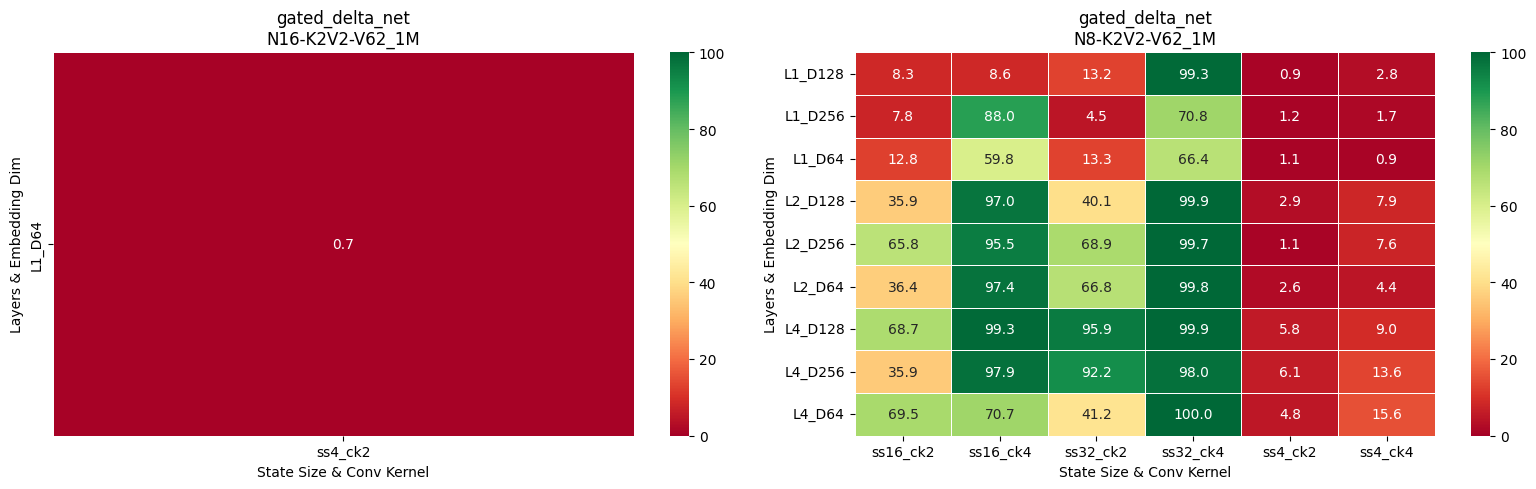

/home/bulatov/envs/mamba/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/bulatov/envs/mamba/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


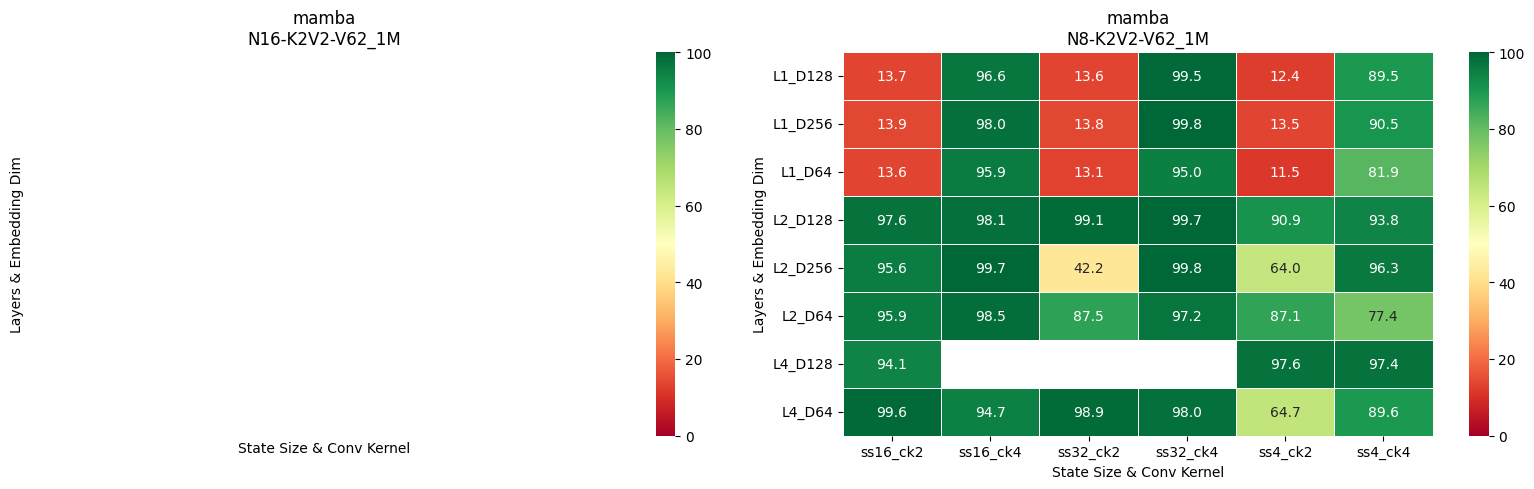

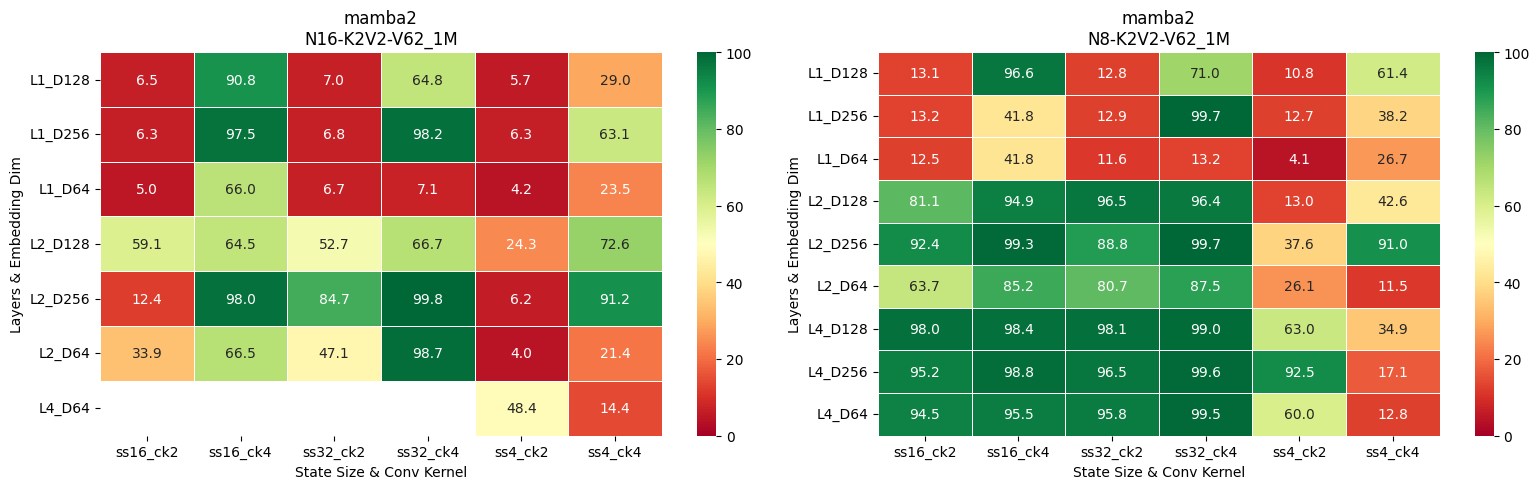

In [20]:
plot_df = grouped.reset_index().copy()

base_models = sorted(plot_df['base_model'].unique())
tasks = sorted(plot_df['task_name'].unique())

for base_model in base_models:
    sub_df = plot_df[plot_df['base_model'] == base_model].copy()
    n_tasks = len(tasks)
    # Set up subplots: n_tasks columns, 1 row
    fig, axes = plt.subplots(1, n_tasks, figsize=(8 * n_tasks, 5), squeeze=False)
    axes = axes[0]  # Flatten, since only one row

    for i, task in enumerate(tasks):
        sub = sub_df[sub_df['task_name'] == task].copy()

        # Compound labels: one unique label per (n_layer, n_embd) combo and per (state_size, conv_kernel) combo
        sub['row_key'] = 'L' + sub['n_layer'].astype(str) + '_D' + sub['n_embd'].astype(str)
        sub['col_key'] = 'ss' + sub['state_size'].astype(str) + '_ck' + sub['conv_kernel'].astype(str)

        pivot = sub.pivot(index='row_key', columns='col_key', values='avg_em')

        ax = axes[i]
        sns.heatmap(pivot, ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
                    annot=True, fmt='.1f', linewidths=0.5)
        ax.set_title(f"{base_model}\n{task}")
        ax.set_xlabel("State Size & Conv Kernel")
        ax.set_ylabel("Layers & Embedding Dim")

    plt.tight_layout()
    plt.show()

In [21]:
# grouped

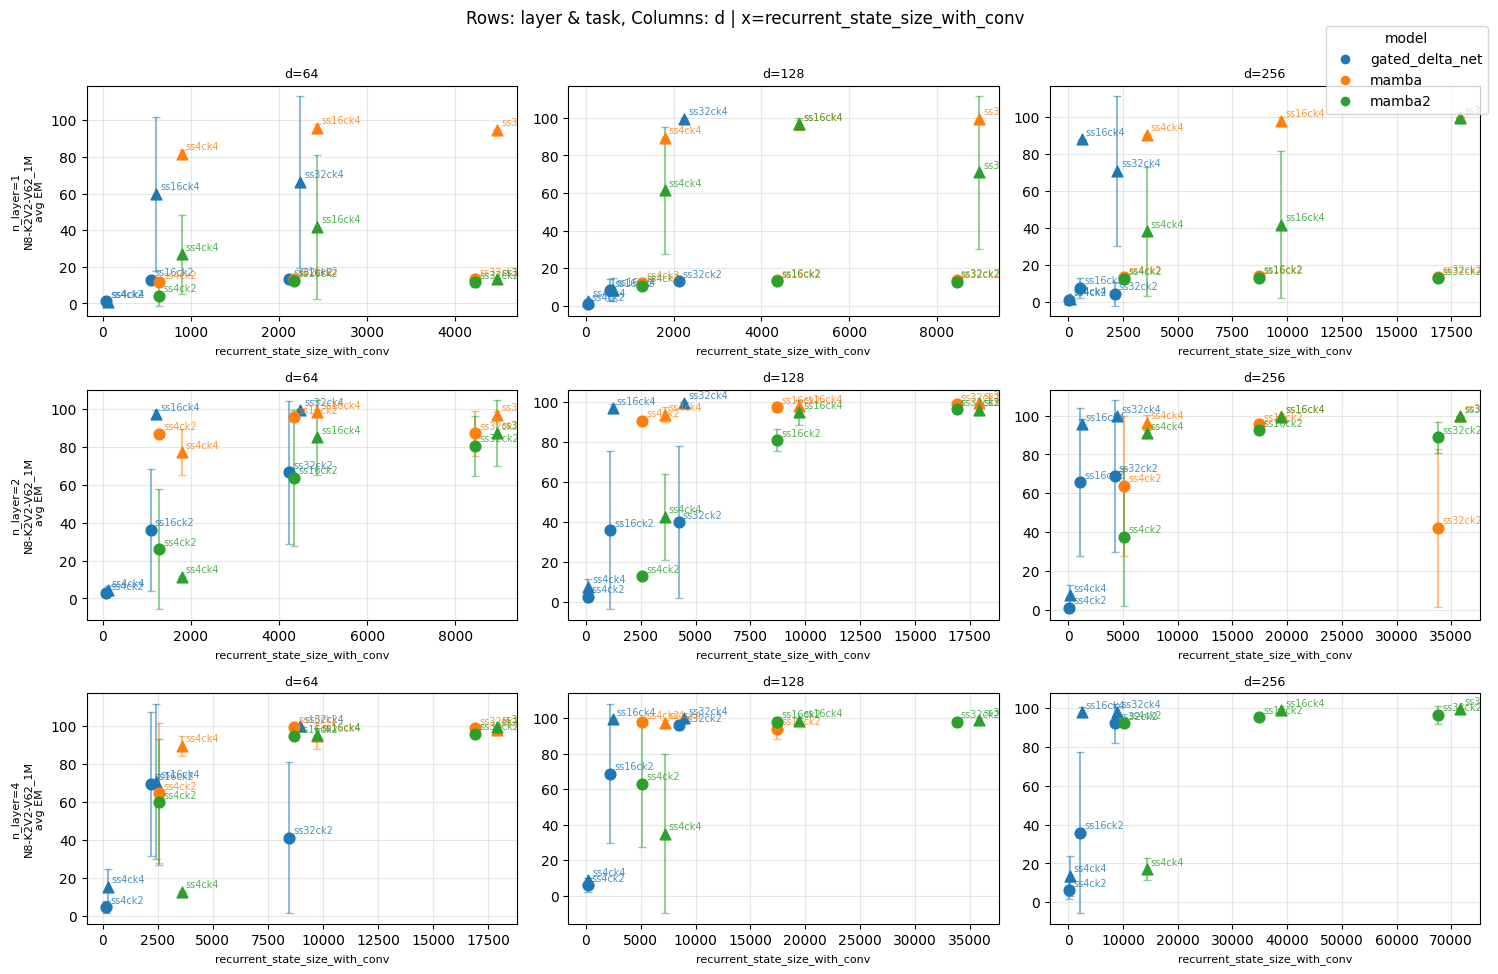

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# X_COL = 'recurrent_state_size'   # or 'recurrent_state_size_with_conv'
X_COL = 'recurrent_state_size_with_conv'

g = grouped.reset_index()
g = g[g.task_name == "N8-K2V2-V62_1M"]

# Instead of filtering for n_layer==1, we keep all and plot each n_layer in a separate row
layer_order    = sorted(g['n_layer'].unique())
nembd_order    = sorted(g['n_embd'].unique())
task_order     = sorted(g['task_name'].unique())
model_order    = sorted(g['base_model'].unique())

palette = dict(zip(model_order, plt.cm.tab10.colors))

# Marker mapping for conv_kernel
ck_marker_map = {2: 'o', 4: '^'}

n_rows = len(layer_order) * len(task_order)
n_cols = len(nembd_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.2 * n_rows),
                         sharey=False, sharex=False)

axes = np.array(axes).reshape(n_rows, n_cols)

for li, n_layer in enumerate(layer_order):
    for ti, task in enumerate(task_order):
        row_index = li * len(task_order) + ti
        for ci, nembd in enumerate(nembd_order):
            ax = axes[row_index, ci]
            sub = g[(g['n_layer'] == n_layer) &
                    (g['task_name'] == task) &
                    (g['n_embd'] == nembd)]
            for model, grp in sub.groupby('base_model'):
                c = palette[model]
                # Draw each point individually with marker depending on conv_kernel
                for _, row in grp.iterrows():
                    marker = ck_marker_map.get(int(row['conv_kernel']), 'o')
                    ax.scatter(row[X_COL], row['avg_em'],
                               color=c, label=model, zorder=3, s=60, marker=marker)
                    # --- label each dot ---
                    label = f"ss{int(row['state_size'])}ck{int(row['conv_kernel'])}"
                    ax.annotate(label,
                                xy=(row[X_COL], row['avg_em']),
                                xytext=(3, 3), textcoords='offset points',
                                fontsize=7, color=c, alpha=0.8,
                                clip_on=True)
                # error bars = std
                ax.errorbar(grp[X_COL], grp['avg_em'],
                            yerr=grp['std_em'],
                            fmt='none', color=c, alpha=0.5, capsize=3)
            if ci == 0:
                ax.set_ylabel(f'n_layer={n_layer}\n{task}\navg EM', fontsize=8)
            else:
                ax.set_ylabel('')
            ax.set_xlabel(X_COL, fontsize=8)
            ax.set_title(f'd={nembd}', fontsize=9)
            ax.grid(True, alpha=0.3)

# single legend (model colors)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[m], markersize=8, label=m)
           for m in model_order]
fig.legend(handles=handles, title='model', loc='upper right',
           bbox_to_anchor=(1.0, 1.0))

# # marker-type legend
# marker_handles = [
#     plt.Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=8, label='ck=2'),
#     plt.Line2D([0], [0], marker='^', color='k', linestyle='None', markersize=8, label='ck=4')
# ]
# fig.legend(handles=marker_handles, title='conv_kernel', loc='upper right',
#            bbox_to_anchor=(1.0, 0.87))

fig.suptitle(f'Rows: layer & task, Columns: d | x={X_COL}', y=1.01)
fig.tight_layout()
fig.savefig('images/compressing_associations_plot.png', dpi=300, bbox_inches='tight')

plt.show()

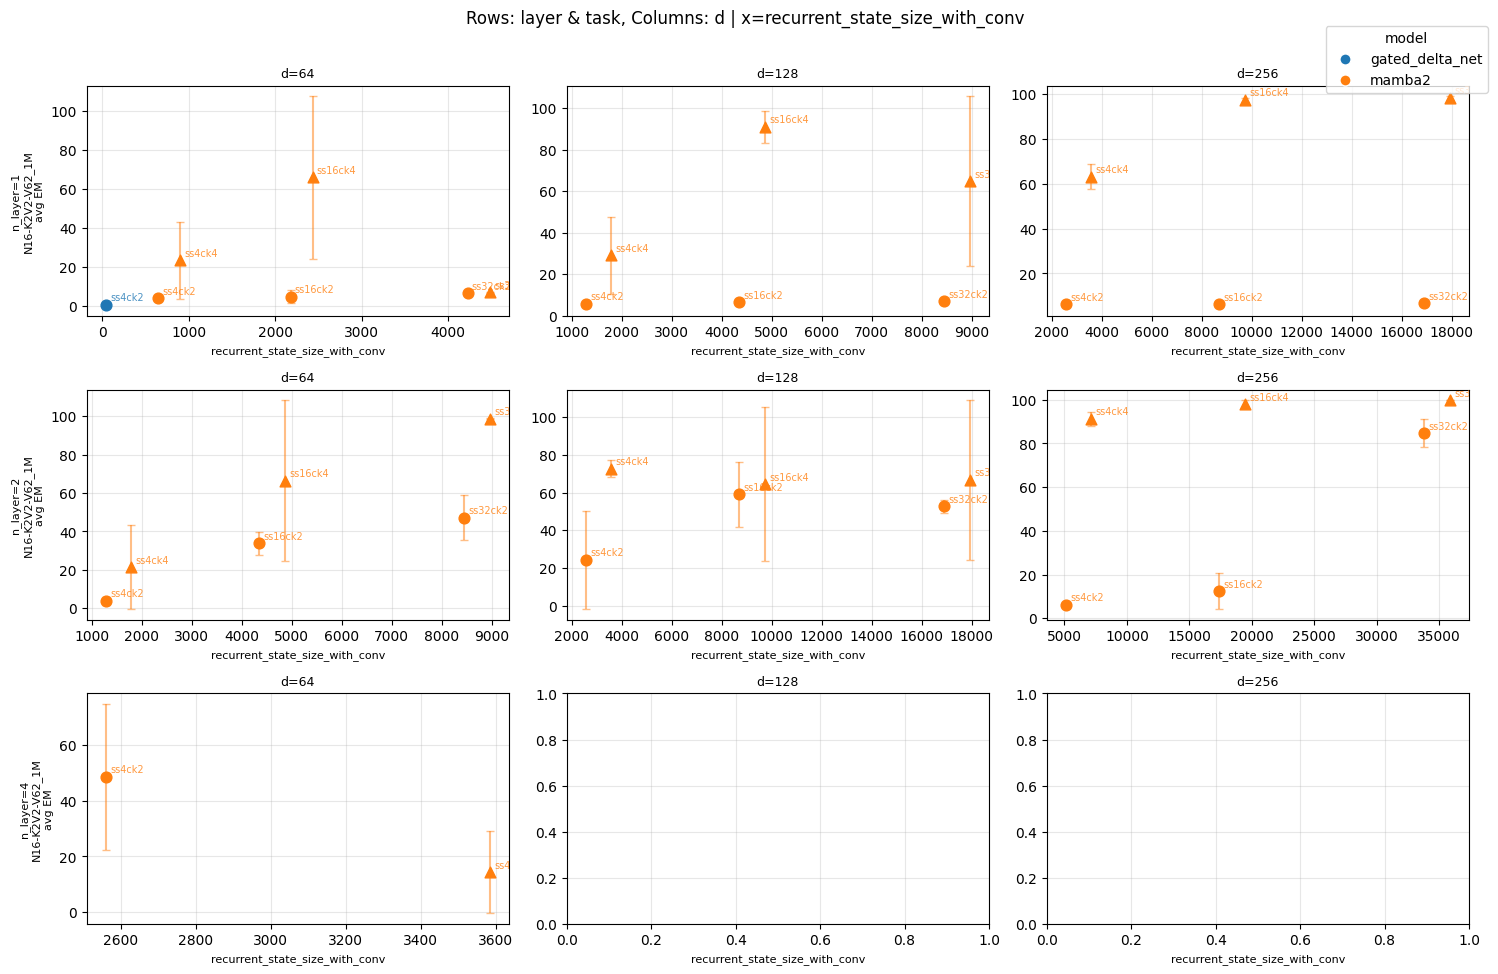

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# X_COL = 'recurrent_state_size'   # or 'recurrent_state_size_with_conv'
X_COL = 'recurrent_state_size_with_conv'

g = grouped.reset_index()
g = g[g.task_name == "N16-K2V2-V62_1M"]

# Instead of filtering for n_layer==1, we keep all and plot each n_layer in a separate row
layer_order    = sorted(g['n_layer'].unique())
nembd_order    = sorted(g['n_embd'].unique())
task_order     = sorted(g['task_name'].unique())
model_order    = sorted(g['base_model'].unique())

palette = dict(zip(model_order, plt.cm.tab10.colors))

# Marker mapping for conv_kernel
ck_marker_map = {2: 'o', 4: '^'}

n_rows = len(layer_order) * len(task_order)
n_cols = len(nembd_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.2 * n_rows),
                         sharey=False, sharex=False)

axes = np.array(axes).reshape(n_rows, n_cols)

for li, n_layer in enumerate(layer_order):
    for ti, task in enumerate(task_order):
        row_index = li * len(task_order) + ti
        for ci, nembd in enumerate(nembd_order):
            ax = axes[row_index, ci]
            sub = g[(g['n_layer'] == n_layer) &
                    (g['task_name'] == task) &
                    (g['n_embd'] == nembd)]
            for model, grp in sub.groupby('base_model'):
                c = palette[model]
                # Draw each point individually with marker depending on conv_kernel
                for _, row in grp.iterrows():
                    marker = ck_marker_map.get(int(row['conv_kernel']), 'o')
                    ax.scatter(row[X_COL], row['avg_em'],
                               color=c, label=model, zorder=3, s=60, marker=marker)
                    # --- label each dot ---
                    label = f"ss{int(row['state_size'])}ck{int(row['conv_kernel'])}"
                    ax.annotate(label,
                                xy=(row[X_COL], row['avg_em']),
                                xytext=(3, 3), textcoords='offset points',
                                fontsize=7, color=c, alpha=0.8,
                                clip_on=True)
                # error bars = std
                ax.errorbar(grp[X_COL], grp['avg_em'],
                            yerr=grp['std_em'],
                            fmt='none', color=c, alpha=0.5, capsize=3)
            if ci == 0:
                ax.set_ylabel(f'n_layer={n_layer}\n{task}\navg EM', fontsize=8)
            else:
                ax.set_ylabel('')
            ax.set_xlabel(X_COL, fontsize=8)
            ax.set_title(f'd={nembd}', fontsize=9)
            ax.grid(True, alpha=0.3)

# single legend (model colors)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[m], markersize=8, label=m)
           for m in model_order]
fig.legend(handles=handles, title='model', loc='upper right',
           bbox_to_anchor=(1.0, 1.0))

# # marker-type legend
# marker_handles = [
#     plt.Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=8, label='ck=2'),
#     plt.Line2D([0], [0], marker='^', color='k', linestyle='None', markersize=8, label='ck=4')
# ]
# fig.legend(handles=marker_handles, title='conv_kernel', loc='upper right',
#            bbox_to_anchor=(1.0, 0.87))

fig.suptitle(f'Rows: layer & task, Columns: d | x={X_COL}', y=1.01)
fig.tight_layout()
fig.savefig('images/compressing_associations_plot-n16.png', dpi=300, bbox_inches='tight')

plt.show()

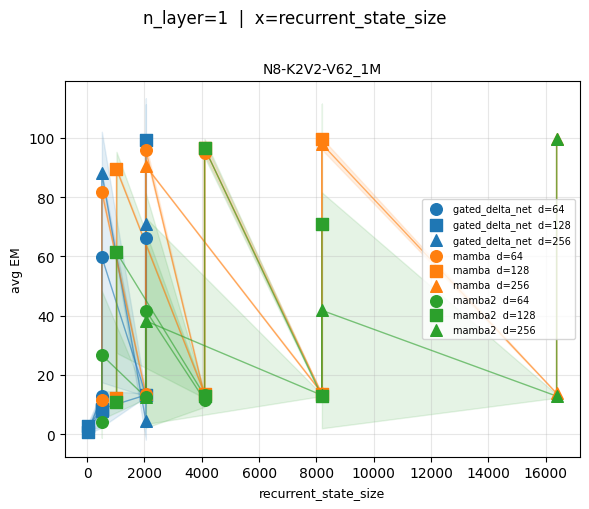

In [23]:
import matplotlib.pyplot as plt
import numpy as np

X_COL = 'recurrent_state_size'   # or 'recurrent_state_size_with_conv'

g = grouped.reset_index()
g = g[g['n_layer'] == 1].copy()

model_order = sorted(g['base_model'].unique())
nembd_order = sorted(g['n_embd'].unique())
task_order  = sorted(g['task_name'].unique())

palette   = dict(zip(model_order, plt.cm.tab10.colors))
markers   = dict(zip(nembd_order, ['o', 's', '^', 'D', 'v'][:len(nembd_order)]))

fig, axes = plt.subplots(1, len(task_order),
                         figsize=(6 * len(task_order), 5),
                         sharey=False)
if len(task_order) == 1:
    axes = [axes]

for ax, task in zip(axes, task_order):
    sub = g[g['task_name'] == task]
    for model, mgrp in sub.groupby('base_model'):
        c = palette[model]
        for nembd, egrp in mgrp.groupby('n_embd'):
            egrp = egrp.sort_values(X_COL)
            xs, ys, es = egrp[X_COL].values, egrp['avg_em'].values, egrp['std_em'].values
            lbl = f'{model}  d={nembd}'
            ax.plot(xs, ys, color=c, alpha=0.6, linewidth=1)
            ax.scatter(xs, ys, color=c, marker=markers[nembd],
                       s=70, zorder=4, label=lbl)
            ax.fill_between(xs, ys - es, ys + es,
                            color=c, alpha=0.12)
    ax.set_title(task, fontsize=10)
    ax.set_xlabel(X_COL, fontsize=9)
    ax.set_ylabel('avg EM', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=1)

fig.suptitle(f'n_layer=1  |  x={X_COL}', y=1.01)
fig.tight_layout()
plt.show()

In [30]:
plot_df = grouped[['avg_em', 'std_em', 'n_runs']].reset_index()
plot_df['avg_em'] = plot_df['avg_em'].round(1)
plot_df['std_em'] = plot_df['std_em'].round(1)

plot_df.sort_values(['task_name', 'base_model', 'n_layer', 'n_embd', 'state_size', 'conv_kernel']) \
    .reset_index(drop=True) \
    .style \
    .background_gradient(subset=['avg_em'], cmap='RdYlGn', vmin=0, vmax=100) \
    .format({'avg_em': '{:.1f}', 'std_em': '±{:.1f}'})

,task_name,base_model,n_layer,n_embd,state_size,conv_kernel,learning_rate,avg_em,std_em,n_runs
0,N8-K2V2-V62_1M,gated_delta_net,1,64,4,2,0.001000,1.1,±0.7,3
1,N8-K2V2-V62_1M,gated_delta_net,1,64,4,4,0.001000,0.9,±1.3,3
2,N8-K2V2-V62_1M,gated_delta_net,1,64,16,2,0.001000,12.8,±0.3,3
3,N8-K2V2-V62_1M,gated_delta_net,1,64,16,4,0.001000,59.8,±42.3,3
4,N8-K2V2-V62_1M,gated_delta_net,1,64,32,2,0.001000,13.3,±0.5,3
5,N8-K2V2-V62_1M,gated_delta_net,1,64,32,4,0.001000,66.4,±46.9,3
6,N8-K2V2-V62_1M,gated_delta_net,1,128,4,2,0.001000,0.9,±0.6,3
7,N8-K2V2-V62_1M,gated_delta_net,1,128,4,4,0.001000,2.8,±1.1,3
8,N8-K2V2-V62_1M,gated_delta_net,1,128,16,2,0.001000,8.4,±5.9,3
9,N8-K2V2-V62_1M,gated_delta_net,1,128,16,4,0.001000,8.6,±6.1,3


In [26]:
plot_df = grouped.reset_index().copy()

# keep only the model/task you want, but do NOT reduce to best_rows / best
plot_df = plot_df[plot_df['base_model'] == 'mamba2'].copy()

plot_df = plot_df[plot_df['n_embd'] == 128]

levels = {
    'n_layer': sorted(plot_df['n_layer'].dropna().unique()),
    'n_embd': sorted(plot_df['n_embd'].dropna().unique()),
    'state_size': sorted(plot_df['state_size'].dropna().unique()),
    'conv_kernel': sorted(plot_df['conv_kernel'].dropna().unique()),
}

def panel_heatmap(sub, y, x, ax, value_col='avg_em', agg='max'):
    panel = (
        sub.groupby([y, x], dropna=False)[value_col]
        .agg(agg)
        .unstack(x)
        .reindex(index=levels[y], columns=levels[x])   # important
    )

    sns.heatmap(
        panel,
        ax=ax,
        cmap='viridis',
        vmin=0, vmax=100,
        annot=True,
        fmt='.1f',
        linewidths=0.5,
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)

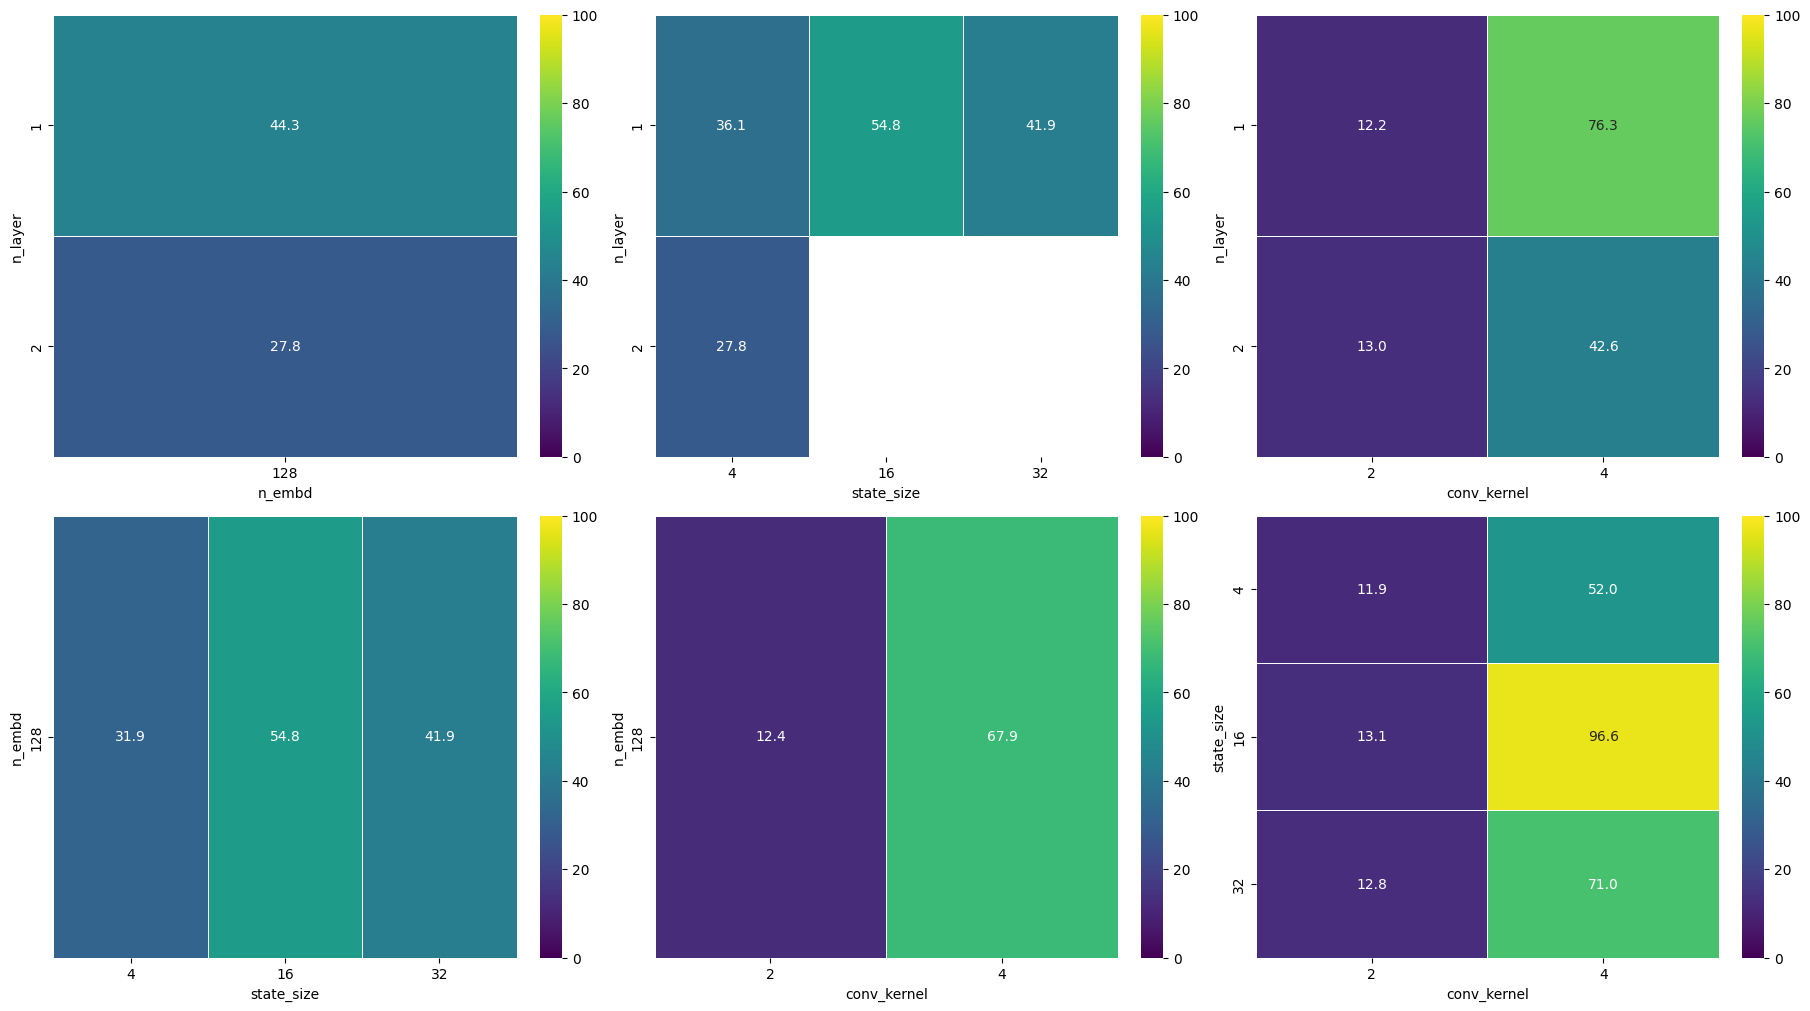

In [27]:
pairs = [
    ('n_layer', 'n_embd'),
    ('n_layer', 'state_size'),
    ('n_layer', 'conv_kernel'),
    ('n_embd', 'state_size'),
    ('n_embd', 'conv_kernel'),
    ('state_size', 'conv_kernel'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (y, x) in zip(axes.flat, pairs):
    panel_heatmap(plot_df, y, x, ax, value_col='avg_em', agg='mean')
plt.show()

In [ ]:
# import itertools
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set_theme(style="whitegrid", context="talk")

# core_params = ['n_layer', 'n_embd', 'state_size', 'conv_kernel']
# nuisance_params = ['per_device_batch_size', 'learning_rate', 'adam_beta2', 'max_steps']

# pretty = {
#     'n_layer': 'Layers',
#     'n_embd': 'Embedding dim',
#     'state_size': 'State size',
#     'conv_kernel': 'Conv kernel',
# }

# # 1) Aggregate only over repeated runs of the exact same config
# cfg_cols = ['task_name', 'n_pairs', 'base_model', *core_params, *nuisance_params]

# cfg_df = (
#     df
#     .dropna(subset=core_params + ['eval_exact_match'])
#     .assign(em_pct=lambda x: x['eval_exact_match'] * 100)
#     .groupby(cfg_cols, dropna=False)
#     .agg(
#         avg_em=('em_pct', 'mean'),
#         std_em=('em_pct', 'std'),
#         n_runs=('em_pct', 'size'),
#     )
#     .reset_index()
# )

# # Optional: focus on one model
# cfg_df = cfg_df[cfg_df['base_model'] == 'mamba2'].copy()


# def plot_pairwise_param_heatmaps(data, facet_col='n_pairs', collapse='max'):
#     pairs = list(itertools.combinations(core_params, 2))
#     facet_values = sorted(data[facet_col].dropna().unique())

#     for facet_value in facet_values:
#         sub = data[data[facet_col] == facet_value].copy()
#         if sub.empty:
#             continue

#         fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
#         fig.suptitle(
#             f"{facet_col} = {facet_value} | color = {collapse}(avg EM) over all other params",
#             fontsize=16,
#         )

#         for i, ((y, x), ax) in enumerate(zip(pairs, axes.flat)):
#             panel = (
#                 sub.groupby([y, x], dropna=False)['avg_em']
#                 .agg(collapse)  # 'max', 'mean', 'median'
#                 .unstack(x)
#                 .sort_index()
#                 .sort_index(axis=1)
#             )

#             sns.heatmap(
#                 panel,
#                 ax=ax,
#                 cmap='viridis',
#                 vmin=0,
#                 vmax=100,
#                 annot=True,
#                 fmt='.1f',
#                 linewidths=0.5,
#                 cbar=(i == len(pairs) - 1),
#             )
#             ax.set_title(f"{pretty[y]} vs {pretty[x]}")
#             ax.set_xlabel(pretty[x])
#             ax.set_ylabel(pretty[y])

#         plt.show()


# plot_pairwise_param_heatmaps(cfg_df, facet_col='n_pairs', collapse='max')

avg_em  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification           
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps       37.91   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps       99.49   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps       46.56   

                                                                   std_em  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification           
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps       27.49   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps        0.21   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps       38.78   

                                                                                                             all_ems  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification                                                      
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps                                          (65.4, 10.42)   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps                                          (99.28, 99.7)   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps      (11.94, 12.98, 94.66, 22.3, 99.84, 99.1, 63.08...   

                                                                   n_runs  
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification          
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps           2  
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps           2  
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps          32

In [52]:
list(df.model.unique())


['rmca_llama',
 'flashrnn_elman',
 'rmca-v1_llama',
 'flashrnn_slstm',
 'gated_delta_net',
 'flashrnn_gru',
 'flashrnn_lstm',
 'rmt_llama',
 'rwkv6',
 'delta_net',
 'rmca-v1.1_llama',
 'linear_attention',
 'mamba2',
 'rmca-gating_llama',
 'rmca-gating-v2_llama',
 'rmca-v2.0-write-order_llama',
 'rmca-v2.0-mem-layers-2R-2W_llama',
 'rmca-v2.0-mem-layers-1R-1W+ff_llama',
 'rmca-v2.0-mem-layers-1R-1W_llama',
 'rmca-v2.0-mem-layers-4R-4W+ff_llama',
 'rmca-v2.0-mem-layers-2R-2W+ff_llama',
 'rmca-v2.0-mem-layers-4R-4W_llama']

In [54]:
target_models = [
    'rmca-gating_llama',
    'rmca-gating-v2_llama',
    'rmca-v2.0-write-order_llama',
    'flashrnn_elman', 
    # 'flashrnn_gru', 
    # 'flashrnn_lstm', 
    'flashrnn_slstm',
    'mamba2',
    'delta_net', 'gated_delta_net',
]

filtered = grouped.reset_index()
filtered = filtered[filtered['model'].isin(target_models)]

best = (
    filtered
    .sort_values(['n_pairs', 'avg_em'], ascending=[True, False])
    .groupby(['n_pairs', 'model', 'mem'], as_index=False)
    .head(1)
    .sort_values(['n_pairs', 'model', 'mem'])
    .set_index(['n_pairs', 'model', 'mem'])
)
display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']
best[display_cols]

learning_rate  avg_em  std_em  \
n_pairs model                       mem                                  
1       flashrnn_elman              0          0.00030  100.00    0.00   
        flashrnn_slstm              0          0.00030  100.00    0.00   
        gated_delta_net             0          0.00030  100.00    0.00   
        rmca-gating-v2_llama        1          0.00100  100.00    0.00   
        rmca-gating_llama           1          0.00005  100.00    0.00   
2       flashrnn_elman              0          0.00100   50.80    0.00   
        flashrnn_slstm              0          0.00030   99.14    0.00   
        rmca-gating_llama           1          0.00100   50.97   33.85   
        rmca-v2.0-write-order_llama 2          0.00010   99.28    0.00   
                                    8          0.00010   99.18    0.00   
                                    32         0.00010   99.16    0.00   
4       delta_net                   0          0.00010   99.97    0.02   
        flashrnn_elman              0          0.00030    7.82    0.00   
        flashrnn_slstm              0          0.00030   84.42    0.00   
        gated_delta_net             0          0.00010  100.00    0.00   
        mamba2                      0          0.00030  100.00    0.00   
        rmca-gating-v2_llama        1          0.00100   23.72    0.00   
        rmca-gating_llama           1          0.00100   13.94    7.95   
        rmca-v2.0-write-order_llama 1          0.00030    7.60    0.00   
                                    2          0.00030   79.80    8.46   
                                    4          0.00030   82.26    0.00   
                                    8          0.00010   90.11    5.70   
                                    16         0.00030   95.29    1.84   
                                    32         0.00010   94.05    4.85   
8       delta_net                   0          0.00010   99.95    0.02   
        flashrnn_elman              0          0.00030    2.74    0.00   
        flashrnn_slstm              0          0.00100   32.91   28.12   
        gated_delta_net             0          0.00010   99.99    0.01   
        mamba2                      0          0.00030   99.94    0.00   
        rmca-gating_llama           1          0.00030    4.83    2.74   
        rmca-v2.0-write-order_llama 1          0.00030    0.82    0.00   
                                    2          0.00010   41.10    0.00   
                                    4          0.00030   11.30    0.00   
                                    8          0.00010   76.54   10.70   
                                    16         0.00030   35.05   24.51   
                                    32         0.00010   92.19    2.96   
16      delta_net                   0          0.00030   99.80    0.03   
        gated_delta_net             0          0.00300   99.97    0.01   
        mamba2                      0          0.00100   99.92    0.00   
        rmca-gating_llama           1          0.00010    0.82    0.36   
        rmca-v2.0-write-order_llama 2          0.00030    0.94    0.00   
                                    8          0.00030    5.44    0.00   
                                    32         0.00010   30.78   34.04   
32      delta_net                   0          0.00030   99.31    0.18   
        gated_delta_net             0          0.00100   99.93    0.01   
        mamba2                      0          0.00100   99.76    0.00   
        rmca-v2.0-write-order_llama 8          0.00010    0.34    0.08   
                                    32         0.00010    0.49    0.10   

                                                                               all_ems  \
n_pairs model                       mem                                                  
1       flashrnn_elman              0                                         (100.0,)   
        flashrnn_slstm              0                                 

In [56]:
target_models = [
    'rmca-v2.0-write-order_llama',
    'rmca-v2.0-mem-layers-2R-2W_llama',
    'rmca-v2.0-mem-layers-1R-1W+ff_llama',
    'rmca-v2.0-mem-layers-1R-1W_llama',
    'rmca-v2.0-mem-layers-4R-4W+ff_llama',
    'rmca-v2.0-mem-layers-2R-2W+ff_llama',
    'rmca-v2.0-mem-layers-4R-4W_llama'
]

filtered = grouped.reset_index()
filtered = filtered[filtered['model'].isin(target_models)]

best = (
    filtered
    .sort_values(['n_pairs', 'avg_em'], ascending=[True, False])
    .groupby(['n_pairs', 'model', 'mem'], as_index=False)
    .head(1)
    .sort_values(['n_pairs', 'model', 'mem'])
    .set_index(['n_pairs', 'model', 'mem'])
)
display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']
best.xs(8, level='n_pairs')[display_cols]

learning_rate  avg_em  std_em  \
model                               mem                                  
rmca-v2.0-mem-layers-1R-1W+ff_llama 8           0.0001   72.04    0.00   
                                    32          0.0001   12.46    0.00   
rmca-v2.0-mem-layers-1R-1W_llama    8           0.0001   86.90    0.00   
                                    32          0.0003   90.12    0.00   
rmca-v2.0-mem-layers-2R-2W+ff_llama 8           0.0003    5.40    0.00   
                                    32          0.0001   12.82    0.00   
rmca-v2.0-mem-layers-2R-2W_llama    8           0.0003    7.06    0.00   
                                    32          0.0001   79.94    0.00   
rmca-v2.0-mem-layers-4R-4W+ff_llama 8           0.0003    2.86    0.00   
                                    32          0.0003    6.36    0.00   
rmca-v2.0-mem-layers-4R-4W_llama    8           0.0003    2.66    0.00   
                                    32          0.0003   12.04    0.00   
rmca-v2.0-write-order_llama         1           0.0003    0.82    0.00   
                                    2           0.0001   41.10    0.00   
                                    4           0.0003   11.30    0.00   
                                    8           0.0001   76.54   10.70   
                                    16          0.0003   35.05   24.51   
                                    32          0.0001   92.19    2.96   

                                                       all_ems  n_runs  
model                               mem                                 
rmca-v2.0-mem-layers-1R-1W+ff_llama 8                 (72.04,)       1  
                                    32                (12.46,)       1  
rmca-v2.0-mem-layers-1R-1W_llama    8                  (86.9,)       1  
                                    32                (90.12,)       1  
rmca-v2.0-mem-layers-2R-2W+ff_llama 8                   (5.4,)       1  
                                    32                (12.82,)       1  
rmca-v2.0-mem-layers-2R-2W_llama    8                  (7.06,)       1  
                                    32                (79.94,)       1  
rmca-v2.0-mem-layers-4R-4W+ff_llama 8                  (2.86,)       1  
                                    32                 (6.36,)       1  
rmca-v2.0-mem-layers-4R-4W_llama    8                  (2.66,)       1  
                                    32                (12.04,)       1  
rmca-v2.0-write-order_llama         1                  (0.82,)       1  
                                    2                  (41.1,)       1  
                                    4                  (11.3,)       1  
                                    8    (88.58, 78.46, 62.58)       3  
                                    16    (2.64, 40.64, 61.88)       3  
                                    32   (90.62, 96.34, 89.62)       3

In [32]:
# target_models = [
#     'rmca-gating_llama',
#     'rmca-v2.0-write-order_llama',
#     'flashrnn_elman', 'flashrnn_gru', 'flashrnn_lstm', 'flashrnn_slstm',
#     'mamba2',
#     'delta_net', 'gated_delta_net',
# ]
# display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']

# filtered = grouped.reset_index()
# filtered = filtered[filtered['model'].isin(target_models)]

# best_lr = (
#     df[df['model'].isin(target_models)]
#     .sort_values(['n_pairs', 'eval_exact_match'], ascending=[True, False])
#     .groupby(['n_pairs', 'model', 'mem'], as_index=False)
#     .first()[['n_pairs', 'model', 'mem', 'learning_rate']]
# )

# best = filtered.merge(best_lr, on=['n_pairs', 'model', 'mem', 'learning_rate'])
# best = best.sort_values(['n_pairs', 'model', 'mem']).set_index(['n_pairs', 'model', 'mem'])
# best[display_cols]

In [11]:
# Select only the best row for each (task_name, model), corresponding to the best memory size, learning rate, and modification, ranked by avg_em
best_rows = grouped.reset_index().sort_values(['n_pairs', 'avg_em'], ascending=[True, False]).groupby(['n_pairs', 'model'], as_index=False).head(1)
# best_rows

In [12]:
best_rows[best_rows.n_pairs == 16]

,n_pairs,model,mem,learning_rate,modification,avg_em,std_em,all_ems,n_runs
161,16,gated_delta_net,0,0.0030,,99.97,0.01,"(99.98, 99.96, 99.98)",3
167,16,mamba2,0,0.0010,,99.92,0.00,"(99.92,)",1
155,16,delta_net,0,0.0003,,99.80,0.03,"(99.8, 99.84, 99.76)",3
174,16,rwkv6,0,0.0003,,86.17,4.42,"(88.3, 90.2, 80.02)",3
171,16,rmca-v2.0-write-order_llama,32,0.0001,2x steps,30.78,34.04,"(78.92, 6.66, 6.76)",3
168,16,rmca-v1.1_llama,8,0.0010,,0.50,0.00,"(0.5,)",1
164,16,linear_attention,0,0.0010,,0.04,0.03,"(0.02, 0.02, 0.08)",3


In [13]:
# group_cols = ['task_name', 'model', 'mem', 'segment', 'learning_rate']
group_cols = ['task_name', 'model', 'mem', 'learning_rate', 'modification']

grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
)

grouped.sort_values(['task_name', 'avg_em'], ascending=[True, False])

avg_em  \
task_name       model                       mem learning_rate modification           
N1-K2V2-V62_1M  flashrnn_elman              0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_gru                0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_lstm               0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_slstm              0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                gated_delta_net             0   0.000300                    100.00   
                                                0.001000                    100.00   
                rmca-v1_llama               8   0.000300                    100.00   
                rmca_llama                  8   0.000300                    100.00   
                                                0.001000                    100.00   
                rmca-v1_llama               8   0.001000                     99.82   
N16-K2V2-V62_1M gated_delta_net             0   0.003000                     99.97   
                                                0.000100                     99.95   
                                                0.000300                     99.94   
                                                0.001000                     99.93   
                mamba2                      0   0.001000                     99.92   
                                                0.000300                     99.84   
                delta_net                   0   0.000300                     99.80   
                                                0.000100                     99.69   
                                                0.001000                     99.61   
                                                0.003000                     99.33   
                rwkv6                       0   0.000300                     86.17   
                                                0.000100                     50.05   
                rmca-v2.0-write-order_llama 32  0.000100      2x steps       30.78   
                                                0.000300      2x steps        3.65   
                                            8   0.000100      2x steps        2.50   
                                                0.000300      2x steps        0.54   
                rmca-v1.1_llama             8   0.001000                      0.50   
                rwkv6                       0   0.001000                      0.06   
                linear_attention            0   0.001000                      0.04   
                rwkv6                       0   0.003000                      0.04   
                linear_attention            0   0.000100                      0.01   
                                                0.000300                      0.01   
                                                0.003000                      0.01   
N2-K2V2-V62_1M  flashrnn_slstm              0   0.000300      2x steps       99.14   
                rmca_llama                  8   0.000300                     98.98   
                                                0.001000                     94.84   
                rmca-v1.1_llama             8   0.001000                     94.74   
                flashrnn_slstm              0   0.001000      2x steps       51.84   
                flashrnn_gru                0   0.000300      2x steps       51.82   
                flashrnn_lstm               0   0.001000      2x steps       51.30   
                flashrnn_gru                0   0.001000      2x steps       51.22   
                flashrnn_elman    

In [15]:
df['model']

,model,model
0,rmca_llama,rmca_llama
1,flashrnn_elman,flashrnn_elman
2,rmca-v1_llama,rmca-v1_llama
3,flashrnn_slstm,flashrnn_slstm
4,rmca-v1_llama,rmca-v1_llama
...,...,...
376,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
377,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
378,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
379,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama


In [ ]:
group_cols = ['task_name', 'model', 'mem', 'segment', 'learning_rate']

grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
).reset_index()

pivot = grouped.pivot_table(
    index=['model', 'mem', 'segment', 'learning_rate'],
    columns='task_name',
    values='avg_em',
)
pivot.sort_index()

task_name                                               N1-K2V2-V62_1M  \
model                       mem  segment learning_rate                   
rmca-v1.1_llama             4.0  1x4     0.000300                  NaN   
                            8.0  1x16    0.001000                  NaN   
                                 1x2     0.001000                  NaN   
                                 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x8     0.001000                  NaN   
                            32.0 1x4     0.000300                  NaN   
rmca-v1_llama               8.0  1x1     0.000300               100.00   
                                         0.001000                99.82   
rmca-v2.0-write-order_llama 1.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            2.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            4.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            8.0  1x4     0.000001                  NaN   
                                         0.000003                  NaN   
                                         0.000010                  NaN   
                                         0.000030                  NaN   
                                         0.000100                  NaN   
                                         0.000300                  NaN   
                                 1x8     0.000001                  NaN   
                                         0.000003                  NaN   
                                         0.000010                  NaN   
                                         0.000030                  NaN   
                                         0.000100                  NaN   
                                         0.000300                  NaN   
                                         0.001000                  NaN   
                                         0.003000                  NaN   
                            16.0 1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            32.0 1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
rmca_llama                  1.0  1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                                         0.001000                  NaN   
                            2.0  1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                            8.0  1x1     0.000300               100.00   
                                         0.001000               100.00   
                                 1x2     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x8     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                                         0.001000                  NaN   
                            16.0 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
    

In [ ]:
# # group_cols = ['model', 'mem', 'task_name', 'n_pairs', 'learning_rate']
# group_cols = ['task_name', 'model', 'mem', 'learning_rate']

# grouped = df.groupby(group_cols, dropna=False).agg(
#     avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
#     std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
#     all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
#     n_runs=('eval_exact_match', 'count'),
# )

# grouped.sort_values(['model', 'mem', 'avg_em'], ascending=[True, True, False])

avg_em  \
task_name       model                       mem  learning_rate           
N4-K2V2-V62_1M  delta_net                   0.0  0.000100        99.97   
                                                 0.003000        99.96   
                                                 0.001000        99.95   
N8-K2V2-V62_1M  delta_net                   0.0  0.000100        99.95   
N4-K2V2-V62_1M  delta_net                   0.0  0.000300        99.94   
N8-K2V2-V62_1M  delta_net                   0.0  0.000300        99.94   
                                                 0.003000        99.86   
                                                 0.001000        99.85   
N16-K2V2-V62_1M delta_net                   0.0  0.000300        99.80   
                                                 0.000100        99.69   
                                                 0.001000        99.61   
                                                 0.003000        99.33   
N32-K2V2-V62_1M delta_net                   0.0  0.000300        99.31   
                                                 0.001000        98.39   
                                                 0.000100        98.12   
                                                 0.003000        98.11   
N1-K2V2-V62_1M  flashrnn_elman              0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_elman              0.0  0.001000        50.80   
                                                 0.000300        48.42   
N4-K2V2-V62_1M  flashrnn_elman              0.0  0.000300         7.82   
                                                 0.001000         5.72   
N8-K2V2-V62_1M  flashrnn_elman              0.0  0.000300         2.74   
                                                 0.001000         1.61   
N1-K2V2-V62_1M  flashrnn_gru                0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_gru                0.0  0.000300        51.82   
                                                 0.001000        51.22   
N4-K2V2-V62_1M  flashrnn_gru                0.0  0.000300        24.96   
                                                 0.001000        23.68   
N8-K2V2-V62_1M  flashrnn_gru                0.0  0.001000         7.74   
                                                 0.000300         2.94   
N1-K2V2-V62_1M  flashrnn_lstm               0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000        51.30   
                                                 0.000300        50.68   
N4-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000        23.26   
                                                 0.000300        22.62   
N8-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000         9.90   
                                                 0.000300         3.70   
                                                 0.010000         0.02   
N1-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        99.14   
N4-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        84.42   
N2-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        51.84   
N8-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        32.91   
N4-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        25.92   
N8-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        14.44   
N1-K2V2-V62_1M  gated_delta_net             0.0  0.000300       100.00   
                                                 0.001000       100.00   
N4-K2V2-V62_1M  gated_delta_net             0.0  0.000100       100.00   
                                                 0.000300       100.